## Filter for sudden drops

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, pickle

In [ ]:
filepath = "data/qpd6_new_solver_test/chi_6/maxwelfare/qpd6_20260108_080215_83fb4cad.pkl"
df = pickle.load(open(filepath, "rb"))
df = pd.DataFrame(df["metric_logs"])

In [10]:
def find_sudden_drops(welfare_sequence, threshold=0.08):
    if not isinstance(welfare_sequence, np.ndarray):
        welfare_sequence = np.array(welfare_sequence)
    mask = welfare_sequence[1:] - welfare_sequence[:-1] < -threshold
    return np.where(mask)[0]

Text(0.5, 1.0, 'Welfare Drop Analysis')

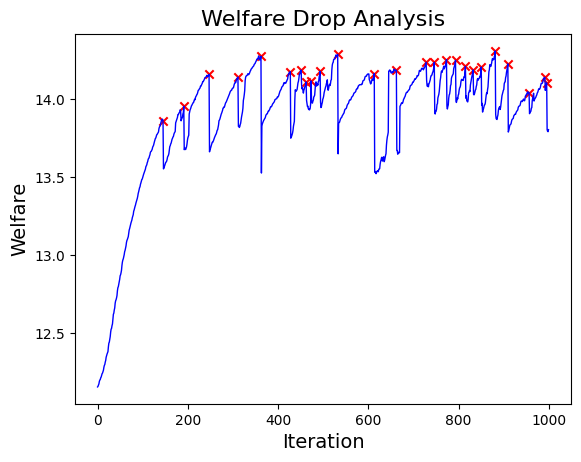

In [27]:
drop_pos = find_sudden_drops(df["welfare"])
plt.plot(df["welfare"], color="blue", linewidth=1)
plt.scatter(drop_pos, df["welfare"][drop_pos], color="red", marker='x')
plt.ylabel("Welfare", fontsize=14)
plt.xlabel("Iteration", fontsize=14)
plt.title("Welfare Drop Analysis", fontsize=16)

In [33]:
states = df['state'].apply(to_comp_basis)
states.tolist()
ent_params = df['ent_params'].tolist()

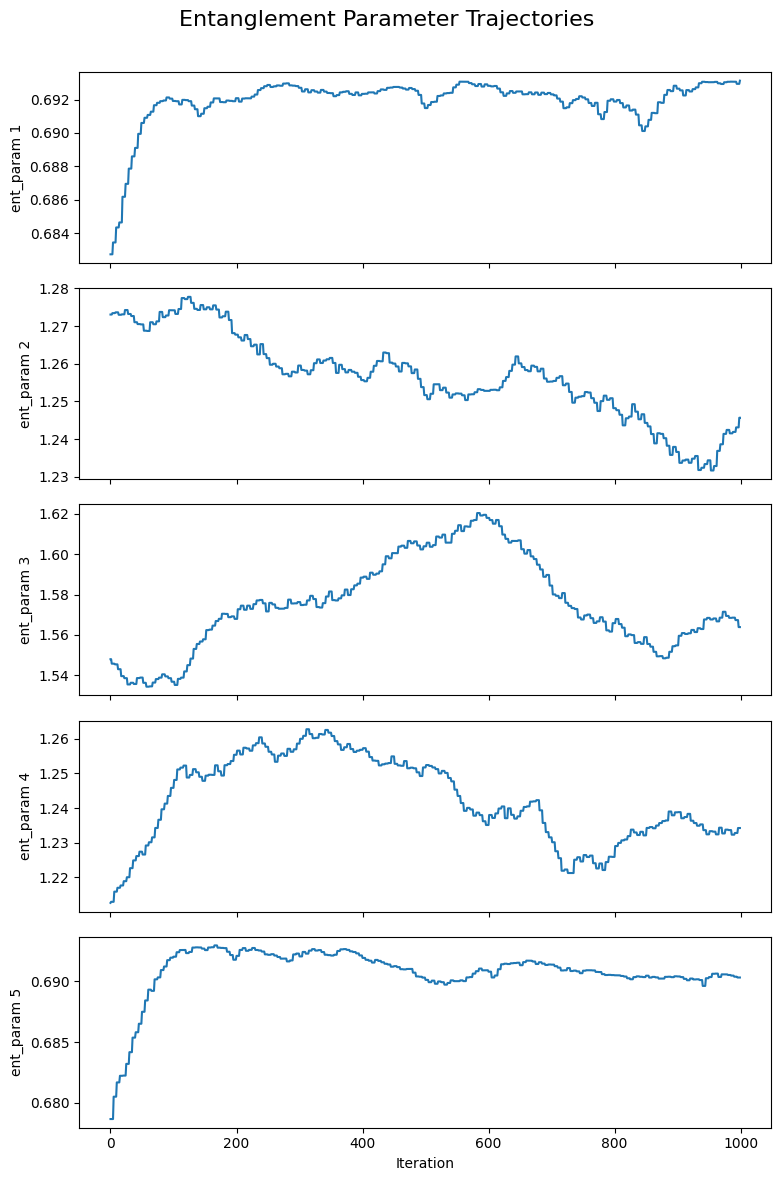

In [36]:
fig, axs = plt.subplots(5, 1, figsize=(8, 12), sharex=True)
ent_params_arr = np.stack(ent_params)
for i in range(5):
    axs[i].plot(ent_params_arr[:, i])
    axs[i].set_ylabel(f'ent_param {i+1}')
axs[-1].set_xlabel("Iteration")
fig.suptitle("Entanglement Parameter Trajectories", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])

### State Fidelity

In [54]:
fidelities = [np.abs(np.vdot(states.iloc[i], states.iloc[i+1]))**2 for i in range(len(states)-1)]

Text(0.5, 1.0, 'Fidelity Between Consecutive States')

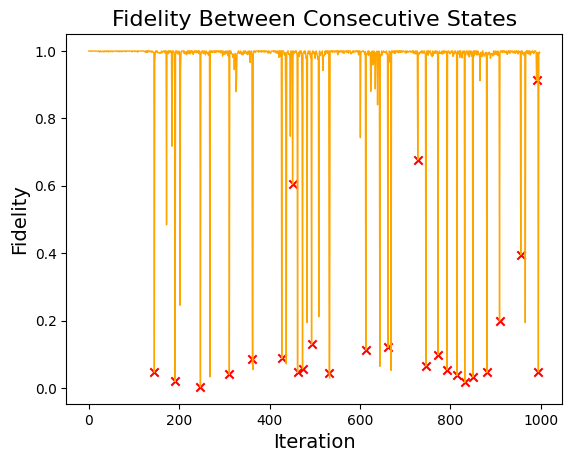

In [66]:
plt.plot(fidelities, linewidth=1, color="orange")
plt.scatter(drop_pos, np.stack(fidelities)[drop_pos], color="red", marker='x')
plt.ylabel("Fidelity", fontsize=14)
plt.xlabel("Iteration", fontsize=14)
plt.title("Fidelity Between Consecutive States", fontsize=16)


## Analyze the first drop

In [307]:
from src.solver import find_nash_eq1, perturb_state, find_nash_eq1_with_retry
from src.game import get_default_cyclic_players
from src.mps_utils import get_rand_state_as_mps

current_index = 2
state = states.iloc[current_index]
site = df['site'].iloc[current_index]
welfare = df['welfare'].iloc[current_index]
print(f"perturbing site {site}")

new_state, _, _ = perturb_state(state, site=2, method="unitary", lr=0.06)
print(np.vdot(new_state, state))


perturbing site 2
(0.9979848339153783+0.0046698467951293565j)


Text(0.5, 1.0, 'Energy Trajectory (Unsuccessful run: alpha=0.08)')

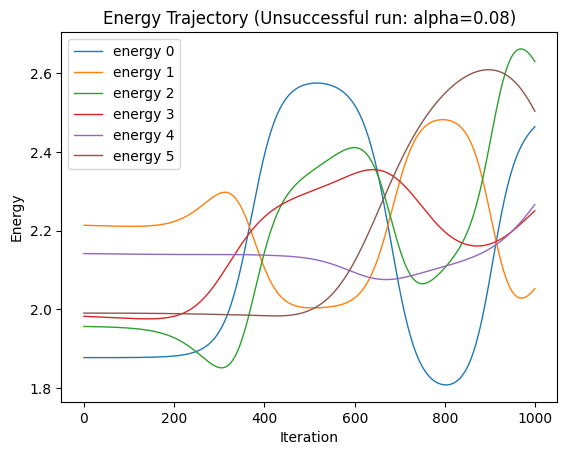

In [312]:
plt.plot(result['energy'], linewidth=1, label=[f"energy {i}" for i in range(6)])
plt.legend()
plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.title("Energy Trajectory (Unsuccessful run: alpha=0.08)")

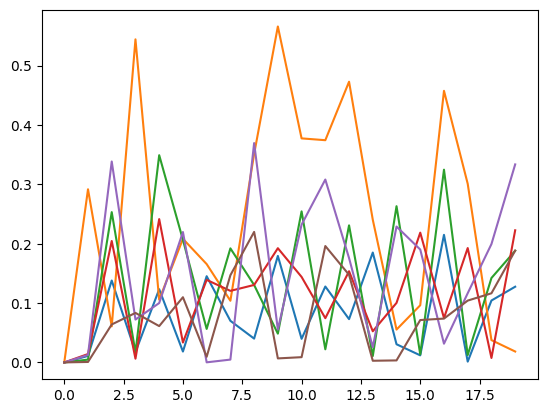

In [299]:
plt.plot(result['expl'])

In [374]:
def plot_energy_and_exploitability(result):
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Left panel: Energy
    axs[0].plot(result['energy']-result['energy'][0], linewidth=1, label=[f"energy {i}" for i in range(6)])
    axs[0].set_xlabel("Iteration")
    axs[0].set_ylabel("Energy")
    axs[0].set_title("Energy Trajectory (Unsuccessful run: alpha=0.08)")
    axs[0].legend()

    # Right panel: Exploitability
    axs[1].plot(result['expl'])
    axs[1].set_xlabel("Iteration")
    axs[1].set_ylabel("Exploitability")
    axs[1].set_title("Exploitability Trajectory")

    plt.tight_layout()
    

In [442]:
# Start from a random state
from copy import deepcopy
from src.mps_utils import from_comp_basis
from src.solver import compute_exploitability
# Psi = get_rand_state_as_mps(6)

current_index = drop_pos[0]-10
Psi = from_comp_basis(states.iloc[current_index])
site = df['site'].iloc[current_index]
welfare = df['welfare'].iloc[current_index]
print(f"perturbing site {site}")

a = deepcopy(Psi)
H = get_default_cyclic_players(6)

M = compute_exploitability(to_comp_basis(Psi).reshape(2, 2, 2, 2, 2, 2), H, 0, maxiter=300, seed=42, real_strategies=True)
print(f"M: {M}")
result = find_nash_eq1(Psi, H, max_iter=1000, alpha=0.4, return_history=True, use_tqdm=True, expl_check_interval=50, expl_maxiter=60, real_strategies=True, expl_threshold=5e-8)
b = deepcopy(Psi)

perturbed_initial_state, _, _ = perturb_state(b, site=4, method="unitary", lr=0.01)
result_perturbed = find_nash_eq1(perturbed_initial_state, H, max_iter=1000, alpha=0.5, return_history=True, use_tqdm=True, expl_check_interval=30, expl_maxiter=300, expl_threshold=1e-16, real_strategies=True)

c = compute_exploitability(result_perturbed['state'][-1], H, 0, maxiter=300, seed=42, real_strategies=True)
print(f"c: {c}")

perturbing site 0
M: 0.0


 18%|█▊        | 180/1000 [00:01<00:05, 144.28it/s]


c: -3.3227376405875475e-10


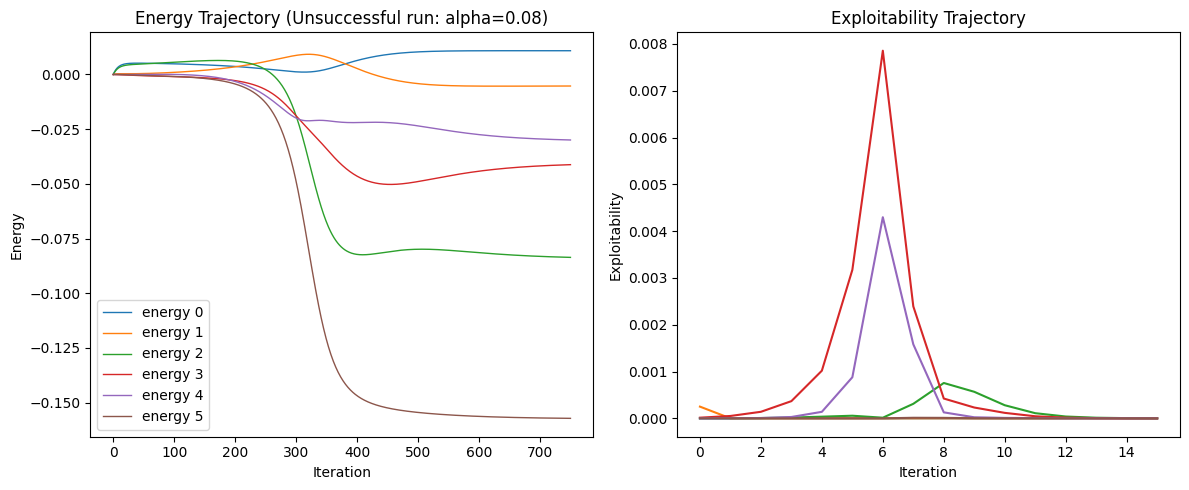

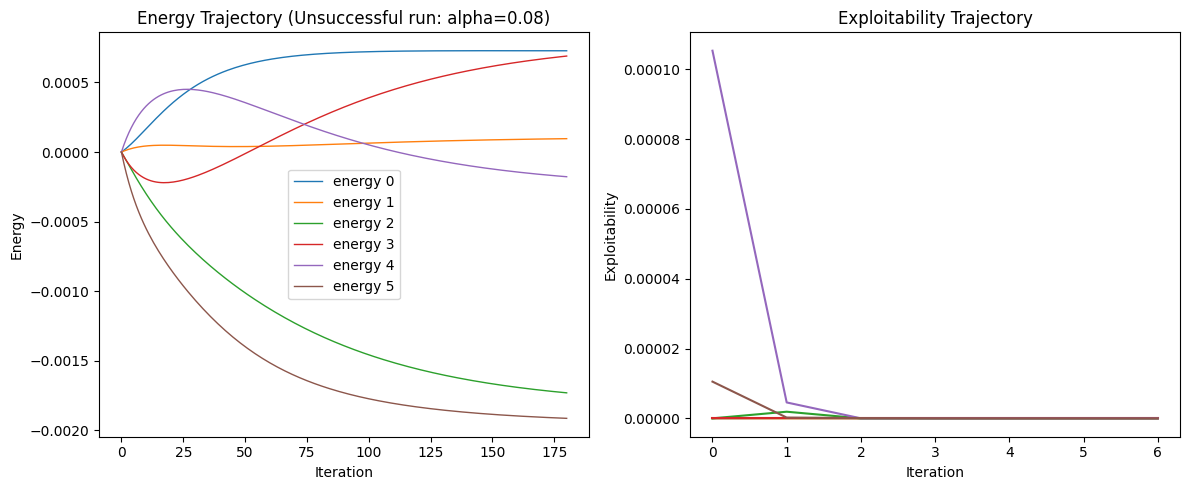

In [443]:
plot_energy_and_exploitability(result)
plot_energy_and_exploitability(result_perturbed)

# fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# # Left panel: Energy
# axs[0].plot(result['energy'], linewidth=1, label=[f"initial {i}" for i in range(6)])
# axs[0].plot(result_perturbed['energy'], linewidth=1, label=[f"perturbed {i}" for i in range(6)], linestyle='--')
# axs[0].set_xlabel("Iteration")
# axs[0].set_ylabel("Energy")
# axs[0].set_title("Energy Trajectory (Unsuccessful run: alpha=0.08)")
# axs[0].legend()

# # Right panel: Exploitability
# axs[1].plot(result['expl'])
# axs[1].plot(result_perturbed['expl'], linestyle='--')
# axs[1].set_xlabel("Iteration")
# axs[1].set_ylabel("Exploitability")
# axs[1].set_title("Exploitability Trajectory")

# plt.tight_layout()

In [459]:
Psi = get_rand_state_as_mps(6, dtype=np.float64)
a = deepcopy(Psi)
result = find_nash_eq1(a, H, max_iter=1000, alpha=0.2, return_history=True, use_tqdm=True, expl_check_interval=50, expl_maxiter=60, real_strategies=True, expl_threshold=5e-12)
expl = compute_exploitability(result['state'][-1], H, 0, maxiter=300, seed=42, real_strategies=True)
print(f"expl: {expl}")

 90%|█████████ | 900/1000 [00:02<00:00, 300.87it/s]

expl: -6.563112275870253e-10


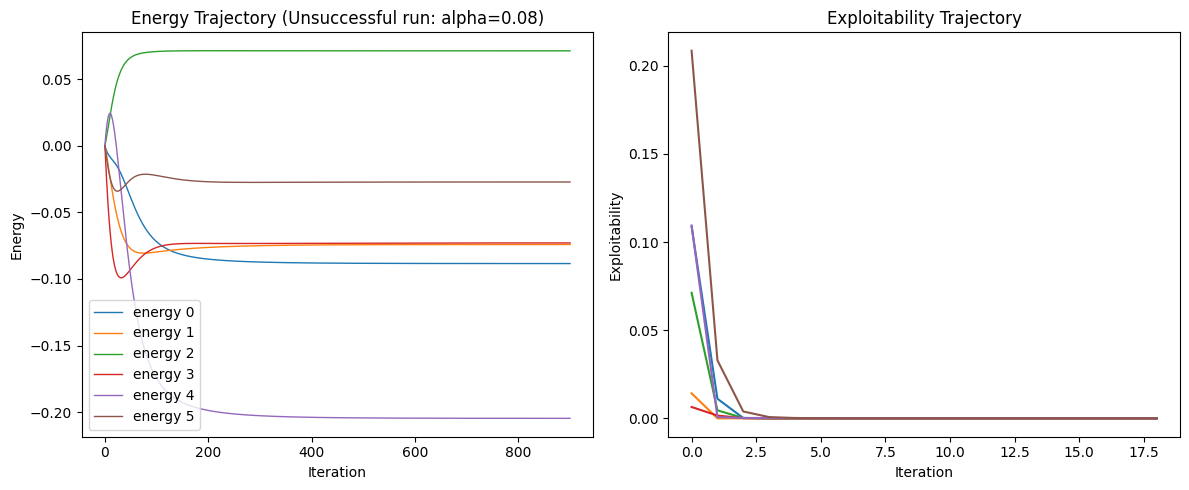

In [460]:
plot_energy_and_exploitability(result)